# Data Prep for EV Population Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

data_path = 'data/raw/3-Electric_Vehicle_Population_Data.csv'
TARGET_COL = 'Electric Range'

data = pd.read_csv(data_path)
print('Shape:', data.shape)
data.head()

print('--- Data Types ---')
print(data.dtypes)
print('\n--- Basic Statistics ---')
print(data.describe(include=[np.number]))


Shape: (150482, 17)
--- Data Types ---
VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                         int64
Base MSRP                                              int64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                              

Step 1: Initial Data Exploration


In [2]:
# Step 1: Initial Data Exploration

print('Shape:', data.shape)

data.head()

print('--- Data Types ---')
print(data.dtypes)
print('\n--- Basic Statistics ---')
data.describe(include=[np.number])

print('\n--- Missing values (quick check) ---')
print(data.isna().sum().sort_values(ascending=False).head(20))


Shape: (150482, 17)
--- Data Types ---
VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                         int64
Base MSRP                                              int64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                              

Step 2: Handling Missing Values


In [10]:
# Step 2: Handling Missing Values

# Identify missing values per column
print('Missing values per column:')
print(data.isna().sum())
print(f"\nTotal missing: {data.isna().sum().sum()}")

# Drop rows where the target is missing
data_clean = data.dropna(subset=[TARGET_COL]).copy()

# Drop columns where more than 50% of values are missing
threshold = len(data_clean) * 0.5
data_clean = data_clean.dropna(thresh=threshold, axis=1)

# Impute numeric columns with median
numeric_cols = data_clean.select_dtypes(include=np.number).columns
if len(numeric_cols) > 0:
    data_clean[numeric_cols] = data_clean[numeric_cols].fillna(data_clean[numeric_cols].median())

# Impute categorical/object columns with mode
categorical_cols = data_clean.select_dtypes(include='object').columns
for col in categorical_cols:
    mode_series = data_clean[col].mode(dropna=True)
    if len(mode_series) > 0:
        data_clean[col] = data_clean[col].fillna(mode_series.iloc[0])

print('\nMissing values after imputation:')
print(data_clean.isna().sum().sort_values(ascending=False).head(20))
print(f"\nShape after handling missing values: {data_clean.shape}")


Missing values per column:
VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 341
DOL Vehicle ID                                         0
Vehicle Location                                       7
Electric Utility                                       3
2020 Census Tract                                      3
dtyp

Step 3: Dealing with Duplicates


In [4]:
# Step 3: Dealing with Duplicates

print(f'Duplicate rows found: {data_clean.duplicated().sum()}')
data_clean = data_clean.drop_duplicates()
print(f'Shape after removing duplicates: {data_clean.shape}')


Duplicate rows found: 0
Shape after removing duplicates: (150482, 17)


Step 4: Handling Categorical Data


In [5]:
# Step 4: Handling Categorical Data
# This dataset has many categorical columns. One-hot encoding for everything can explode feature size,
# so we use:
# - One-hot encoding for low-cardinality categorical columns
# - Frequency encoding for high-cardinality categorical columns

candidate_cat_cols = [
    'County',
    'City',
    'State',
    'Postal Code',
    'Make',
    'Model',
    'Electric Vehicle Type',
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
    'Electric Utility',
    'Legislative District',
    '2020 Census Tract',
]

# Keep only those that exist
nominal_cols = [c for c in candidate_cat_cols if c in data_clean.columns]

# Drop some identifiers/location-like columns (optional; helps reduce noise)
# If your instructor wants them encoded instead, remove these from the list.
drop_like_cols = [c for c in ['VIN (1-10)', 'DOL Vehicle ID', 'Vehicle Location'] if c in data_clean.columns]

data_clean = data_clean.drop(columns=drop_like_cols, errors='ignore')

# Ensure categorical columns are strings (consistent category labels)
for col in nominal_cols:
    if col in data_clean.columns:
        data_clean[col] = data_clean[col].astype(str)

ONEHOT_THRESHOLD = 50
onehot_cols = [c for c in nominal_cols if c in data_clean.columns and data_clean[c].nunique(dropna=True) <= ONEHOT_THRESHOLD]
freq_cols = [c for c in nominal_cols if c in data_clean.columns and c not in onehot_cols]

print('One-hot columns:', onehot_cols)
print('Frequency-encoded columns:', freq_cols)

# One-hot encode low-cardinality columns
# (drop_first=False so you keep full info)
data_encoded = pd.get_dummies(data_clean, columns=onehot_cols, drop_first=False)

# Frequency encode high-cardinality columns
for col in freq_cols:
    freq_map = data_clean[col].value_counts(dropna=True, normalize=True)
    data_encoded[col + '__freq'] = data_clean[col].map(freq_map).fillna(0.0).astype(float)

# Drop original high-cardinality columns
if len(freq_cols) > 0:
    data_encoded = data_encoded.drop(columns=freq_cols, errors='ignore')

print(f'Shape after categorical encoding: {data_encoded.shape}')
data_encoded.head()


One-hot columns: ['State', 'Make', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Legislative District']
Frequency-encoded columns: ['County', 'City', 'Postal Code', 'Model', 'Electric Utility', '2020 Census Tract']
Shape after categorical encoding: (150482, 141)


,Model Year,Electric Range,Base MSRP,State_AK,State_AL,State_AP,State_AR,State_AZ,State_BC,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_MN,State_MO,State_MS,State_MT,State_NC,State_NE,State_NH,State_NJ,State_NV,State_NY,State_OH,State_OR,State_PA,State_SC,State_TX,State_UT,State_VA,State_WA,State_WY,Make_ALFA ROMEO,Make_AUDI,Make_AZURE DYNAMICS,Make_BENTLEY,Make_BMW,Make_CADILLAC,Make_CHEVROLET,Make_CHRYSLER,Make_FIAT,Make_FISKER,Make_FORD,Make_GENESIS,Make_HONDA,Make_HYUNDAI,Make_JAGUAR,Make_JEEP,Make_KIA,Make_LAND ROVER,Make_LEXUS,Make_LINCOLN,Make_LUCID,Make_MAZDA,Make_MERCEDES-BENZ,Make_MINI,Make_MITSUBISHI,Make_NISSAN,Make_POLESTAR,Make_PORSCHE,Make_RIVIAN,Make_SMART,Make_SUBARU,Make_TESLA,Make_TH!NK,Make_TOYOTA,Make_VOLKSWAGEN,Make_VOLVO,Make_WHEEGO ELECTRIC CARS,Electric Vehicle Type_Battery Electric Vehicle (BEV),Electric Vehicle Type_Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle (CAFV) Eligibility_Clean Alternative Fuel Vehicle Eligible,Clean Alternative Fuel Vehicle (CAFV) Eligibility_Eligibility unknown as battery range has not been researched,Clean Alternative Fuel Vehicle (CAFV) Eligibility_Not eligible due to low battery range,Legislative District_1.0,Legislative District_10.0,Legislative District_11.0,Legislative District_12.0,Legislative District_13.0,Legislative District_14.0,Legislative District_15.0,Legislative District_16.0,Legislative District_17.0,Legislative District_18.0,Legislative District_19.0,Legislative District_2.0,Legislative District_20.0,Legislative District_21.0,Legislative District_22.0,Legislative District_23.0,Legislative District_24.0,Legislative District_25.0,Legislative District_26.0,Legislative District_27.0,Legislative District_28.0,Legislative District_29.0,Legislative District_3.0,Legislative District_30.0,Legislative District_31.0,Legislative District_32.0,Legislative District_33.0,Legislative District_34.0,Legislative District_35.0,Legislative District_36.0,Legislative District_37.0,Legislative District_38.0,Legislative District_39.0,Legislative District_4.0,Legislative District_40.0,Legislative District_41.0,Legislative District_42.0,Legislative District_43.0,Legislative District_44.0,Legislative District_45.0,Legislative District_46.0,Legislative District_47.0,Legislative District_48.0,Legislative District_49.0,Legislative District_5.0,Legislative District_6.0,Legislative District_7.0,Legislative District_8.0,Legislative District_9.0,County__freq,City__freq,Postal Code__freq,Model__freq,Electric Utility__freq,2020 Census Tract__freq
0,2020,258,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,0.525498,0.170638,0.012560,0.001382,0.181204,0.001469
1,2022,25,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,Fal

Step 5: Data Manipulation & Outlier Management


In [6]:
# Step 5: Data Manipulation & Outlier Management

# Discretization-style feature: Vehicle Age
if 'Model Year' in data_encoded.columns:
    max_year = int(pd.to_numeric(data_encoded['Model Year'], errors='coerce').max())
    data_encoded['Vehicle Age'] = max_year - pd.to_numeric(data_encoded['Model Year'], errors='coerce')

# Outlier capping (±3 standard deviations)
numeric_features = data_encoded.select_dtypes(include=np.number).columns.tolist()

# Exclude the target and dummy-like/binary features from capping
exclude_cols = [TARGET_COL] + [c for c in numeric_features if data_encoded[c].nunique() <= 2]
cap_cols = [c for c in numeric_features if c not in exclude_cols]

outlier_counts = {}
for col in cap_cols:
    mean, std = data_encoded[col].mean(), data_encoded[col].std()
    if std == 0 or np.isnan(std):
        continue
    lower, upper = mean - 3 * std, mean + 3 * std
    n_outliers = ((data_encoded[col] < lower) | (data_encoded[col] > upper)).sum()
    if n_outliers > 0:
        outlier_counts[col] = int(n_outliers)
    data_encoded[col] = data_encoded[col].clip(lower, upper)

print(f"Outliers capped per column (top 15): {dict(sorted(outlier_counts.items(), key=lambda x: -x[1])[:15])}")
print(f"Shape after outlier treatment: {data_encoded.shape}")


Outliers capped per column (top 15): {'Postal Code__freq': 3869, 'Base MSRP': 3455, '2020 Census Tract__freq': 2721, 'Model Year': 60, 'Vehicle Age': 60}
Shape after outlier treatment: (150482, 142)


Step 6: Data Partitioning (Train / Validation / Test)

Same strategy as `1-vehicle_emission_data_prep.ipynb`: hold out 20% test, then split the remainder 75% train / 25% validation → **~60% / 20% / 20%** overall. No stratification (regression target).


In [7]:
# Step 6: Data Partitioning (Train / Validation / Test)

X = data_encoded.drop(columns=[TARGET_COL])
y = data_encoded[TARGET_COL]

# Stage 1: hold out 20% as the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Stage 2: split remainder into 75% train / 25% validation → 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set:    {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set:  {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:        {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print("\nTarget stats (train):")
print(y_train.describe())


Training set:  120385 rows (80.0%)
Test set:      30097 rows (20.0%)

Target stats (train):
count    120385.000000
mean         67.895627
std          96.199412
min           0.000000
25%           0.000000
50%          19.000000
75%          97.000000
max         337.000000
Name: Electric Range, dtype: float64


Step 7: Feature Scaling


In [9]:
# Step 7: Feature Scaling (leakage-free: fit on train only)

# Scale only continuous numeric features (exclude binary dummy columns)
scale_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if X_train[c].nunique() > 2
]

# --- Standardization (preferred: mean=0, std=1) ---
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Standardization applied to:", scale_cols[:25], "..." if len(scale_cols) > 25 else "")
print(f"\nTrain feature means (should be ~0):\n{X_train_scaled[scale_cols].mean().round(4)}")
print(f"\nTrain feature std (should be ~1):\n{X_train_scaled[scale_cols].std().round(4)}")

# --- MinMax Normalization (for reference) ---
minmax = MinMaxScaler()
X_train_norm = X_train.copy()
X_val_norm = X_val.copy()
X_test_norm = X_test.copy()

X_train_norm[scale_cols] = minmax.fit_transform(X_train[scale_cols])
X_val_norm[scale_cols] = minmax.transform(X_val[scale_cols])
X_test_norm[scale_cols] = minmax.transform(X_test[scale_cols])

print(f"\nMinMax range check (train) — min:\n{X_train_norm[scale_cols].min().round(4)}")
print(f"\nMinMax range check (train) — max:\n{X_train_norm[scale_cols].max().round(4)}")

Standardization applied to: ['Model Year', 'County__freq', 'City__freq', 'Postal Code__freq', 'Model__freq', 'Electric Utility__freq', '2020 Census Tract__freq', 'Vehicle Age'] 

Train feature means (should be ~0):
Model Year                 0.0
County__freq               0.0
City__freq                 0.0
Postal Code__freq         -0.0
Model__freq               -0.0
Electric Utility__freq     0.0
2020 Census Tract__freq    0.0
Vehicle Age                0.0
dtype: float64

Train feature std (should be ~1):
Model Year                 1.0
County__freq               1.0
City__freq                 1.0
Postal Code__freq          1.0
Model__freq                1.0
Electric Utility__freq     1.0
2020 Census Tract__freq    1.0
Vehicle Age                1.0
dtype: float64

MinMax range check (train) — min:
Model Year                 0.0
County__freq               0.0
City__freq                 0.0
Postal Code__freq          0.0
Model__freq                0.0
Electric Utility__freq     0.0
202

Step 8: Visualizing Data


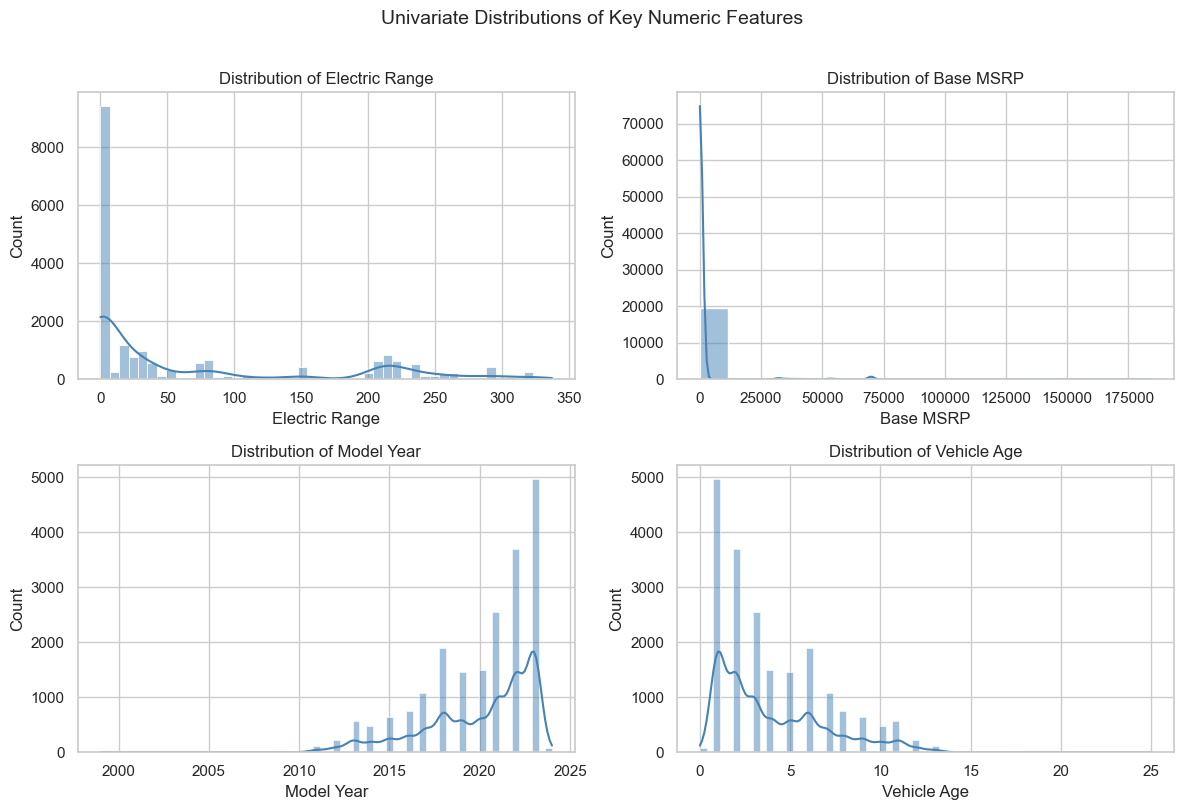

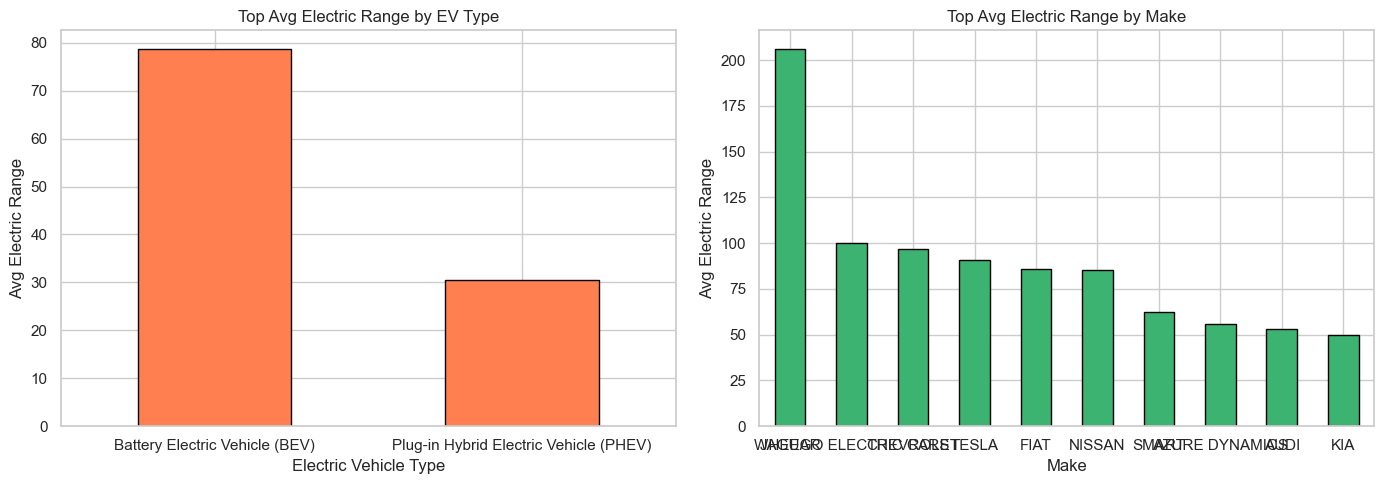

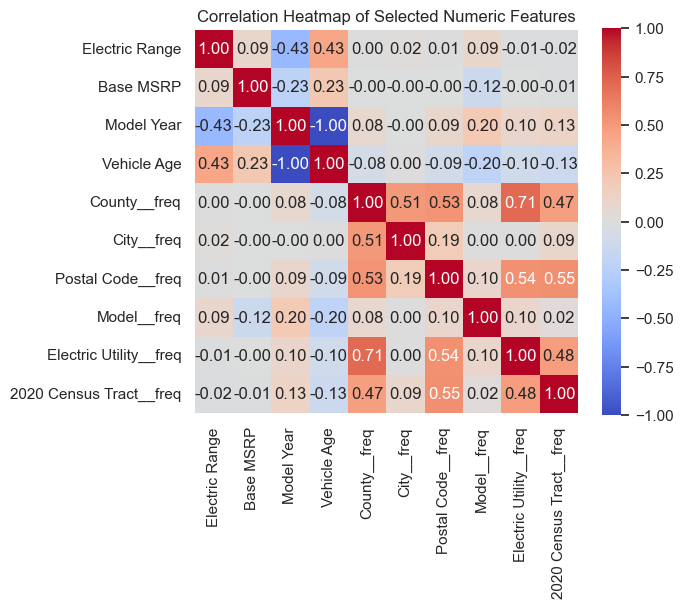

In [11]:
# Step 8: Visualizing Data

# Use sample for faster plotting
plot_df_raw = data_clean.copy()  # data_clean is before encoding
if 'Model Year' in plot_df_raw.columns and 'Vehicle Age' not in plot_df_raw.columns:
    max_year = int(pd.to_numeric(plot_df_raw['Model Year'], errors='coerce').max())
    plot_df_raw['Vehicle Age'] = max_year - pd.to_numeric(plot_df_raw['Model Year'], errors='coerce')

plot_df_raw = plot_df_raw.sample(n=min(20000, len(plot_df_raw)), random_state=42)

# --- Univariate Distributions ---
cont_features = [TARGET_COL]
for c in ['Base MSRP', 'Model Year', 'Vehicle Age']:
    if c in plot_df_raw.columns:
        cont_features.append(c)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cont_features):
    sns.histplot(plot_df_raw[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

for j in range(len(cont_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions of Key Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Multivariate: Avg Electric Range by categories ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Electric Vehicle Type' in plot_df_raw.columns:
    ev_avg = plot_df_raw.groupby('Electric Vehicle Type')[TARGET_COL].mean().sort_values(ascending=False)
    ev_avg.head(10).plot.bar(ax=axes[0], color='coral', edgecolor='black')
    axes[0].set_title('Top Avg Electric Range by EV Type')
    axes[0].set_xlabel('Electric Vehicle Type')
    axes[0].set_ylabel('Avg Electric Range')
    axes[0].tick_params(axis='x', rotation=0)

if 'Make' in plot_df_raw.columns:
    make_avg = plot_df_raw.groupby('Make')[TARGET_COL].mean().sort_values(ascending=False).head(10)
    make_avg.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='black')
    axes[1].set_title('Top Avg Electric Range by Make')
    axes[1].set_xlabel('Make')
    axes[1].set_ylabel('Avg Electric Range')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# --- Correlation Heatmap ---
# Correlation on numeric columns from the encoded dataset
numeric_cols_plot = [c for c in [TARGET_COL, 'Base MSRP', 'Model Year', 'Vehicle Age'] if c in data_encoded.columns]
# Add a few frequency-encoded features if present
freq_candidates = [c for c in data_encoded.columns if c.endswith('__freq')]
numeric_cols_plot += freq_candidates[:10]

numeric_cols_plot = list(dict.fromkeys(numeric_cols_plot))  # unique, preserve order

if len(numeric_cols_plot) >= 2:
    corr = data_encoded[numeric_cols_plot].corr()
    plt.figure(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Heatmap of Selected Numeric Features')
    plt.tight_layout()
    plt.show()


## Export: Processed Dataset + Scaled Splits

Mirrors `1-vehicle_emission_data_prep.ipynb`: full encoded modeling frame is saved, plus **StandardScaler** train/validation/test feature matrices and targets (`Electric Range`).


In [ ]:
import os

os.makedirs('data/processed', exist_ok=True)

# Full processed (encoded) dataset — same rows as data_encoded
data_encoded.to_csv('data/processed/3-EV_population_data_cleaned.csv', index=False)
print(f"Saved full processed dataset: {data_encoded.shape} → 3-EV_population_data_cleaned.csv")

# Scaled train / validation / test (StandardScaler, leakage-free)
X_train_scaled.to_csv('data/processed/3-EV_population_data_X_train.csv', index=False)
X_val_scaled.to_csv('data/processed/3-EV_population_data_X_val.csv', index=False)
X_test_scaled.to_csv('data/processed/3-EV_population_data_X_test.csv', index=False)
y_train.to_csv('data/processed/3-EV_population_data_y_train.csv', index=False, header=True)
y_val.to_csv('data/processed/3-EV_population_data_y_val.csv', index=False, header=True)
y_test.to_csv('data/processed/3-EV_population_data_y_test.csv', index=False, header=True)

print("Saved splits:")
print(f"  X_train: {X_train_scaled.shape}  →  3-EV_population_data_X_train.csv")
print(f"  X_val:   {X_val_scaled.shape}   →  3-EV_population_data_X_val.csv")
print(f"  X_test:  {X_test_scaled.shape}   →  3-EV_population_data_X_test.csv")
print(f"  y_train / y_val / y_test  →  3-EV_population_data_y_*.csv")
print(f"\nTarget column: {TARGET_COL}")
